# SENTIMENT ANALYSIS FOR SUPPLY CHAIN FORECASTING
# Dataset: Amazon Fashion Reviews (800K+ reviews)
# Models: VADER (baseline) + DistilBERT (fine-tuned)
# Purpose: Generate supplier sentiment scores for demand forecasting


STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import re

# Deep Learning Libraries
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


All libraries imported successfully!
PyTorch version: 2.10.0+cu128
CUDA available: True


STEP 2: LOAD AMAZON FASHION REVIEWS DATASET


In [2]:
#  Import libraries
import pandas as pd
from google.colab import files

print("Upload your CSV file...")

# Upload file
uploaded = files.upload()

# Read CSV directly
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display info
print(f"\nFile uploaded: {file_name}")
print(f"\nFile loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

print("\nSample Data:")
display(df.head())

Upload your CSV file...


Saving amazon-fashion-800k+-user-reviews-dataset.csv to amazon-fashion-800k+-user-reviews-dataset.csv

File uploaded: amazon-fashion-800k+-user-reviews-dataset.csv

File loaded successfully!
Total rows: 867,310
Dataset shape: (867310, 11)

Column names:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchases', 'target']

Sample Data:


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchases,target
0,1.0,It say 5 pair when purchasing but only get 2 r...,I was looking for 5 pair and only received 2 p...,[],B07QFTMTLP,B07QFTMTLP,AHASEZ65RESN57BMGRV6QBM5DTIA,1565088068852,0,True,-1
1,1.0,DonÃ¢ÂÂt do it!,Just donÃ¢ÂÂt. These things fell apart after...,[],B0764KKDN1,B0764KKDN1,AE3AMA3QSOHFKV46JJAHTHMMIR6A,1622416429592,0,True,-1
2,1.0,Small,Retuned is too small for me,[],B07J1WHVCP,B07J1WHVCP,AH4CFWQE2HTC5BSWIEF3LVLUFK6A,1565284666220,0,True,-1
3,1.0,Pre-Used When Received,This product came with the sleeves turned insi...,[],B0773JWP64,B0773JWP64,AFEKQFJWST6MVTKEJBQKUUBTWK7A,1581963636172,0,False,-1
4,1.0,Worn once and several places at seams have com...,Worn once and several places at seams have com...,[],B099NST9RX,B08JGNS1NK,AGU2FPKN6ARXUSSGBT6WTVLZKJSQ,1640895438476,0,True,-1


STEP 3: INITIAL DATA EXPLORATION

In [4]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

# Basic info
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

# Check unique values
print(f"\nUnique products (ASIN): {df['asin'].nunique():,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Rating distribution:")
print(df['rating'].value_counts().sort_index())

DATASET OVERVIEW

First 5 rows:
   rating                                              title  \
0     1.0  It say 5 pair when purchasing but only get 2 r...   
1     1.0                                  DonÃ¢ÂÂt do it!   
2     1.0                                              Small   
3     1.0                             Pre-Used When Received   
4     1.0  Worn once and several places at seams have com...   

                                                text images        asin  \
0  I was looking for 5 pair and only received 2 p...     []  B07QFTMTLP   
1  Just donÃ¢ÂÂt. These things fell apart after...     []  B0764KKDN1   
2                        Retuned is too small for me     []  B07J1WHVCP   
3  This product came with the sleeves turned insi...     []  B0773JWP64   
4  Worn once and several places at seams have com...     []  B099NST9RX   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B07QFTMTLP  AHASEZ65RESN57BMGRV6QBM5DTIA  15650880688

STEP 4: VISUALIZE RATING DISTRIBUTION

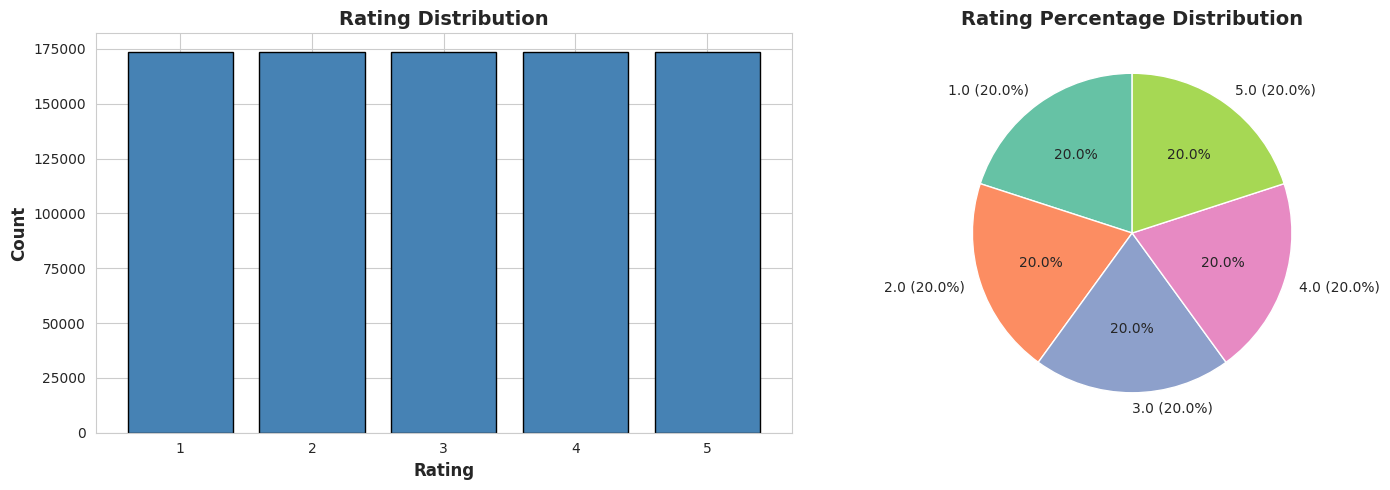


Rating Statistics:
Mean rating: 3.00
Median rating: 3.00
Mode rating: 1.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Rating percentage
rating_pct = (rating_counts / len(df) * 100).round(2)
axes[1].pie(rating_pct, labels=[f'{i} ({rating_pct[i]}%)' for i in rating_pct.index],
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[1].set_title('Rating Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRating Statistics:")
print(f"Mean rating: {df['rating'].mean():.2f}")
print(f"Median rating: {df['rating'].median():.2f}")
print(f"Mode rating: {df['rating'].mode()[0]}")



STEP 5: SAMPLE DATA FOR FASTER PROCESSING

In [8]:
SAMPLE_SIZE = 50000
np.random.seed(42)

# Stratified sampling to maintain rating distribution
df_sample = df.groupby('rating', group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 5))
).reset_index(drop=True)

print(f" Sampled {len(df_sample):,} reviews")
print(f"\nSample rating distribution:")
print(df_sample['rating'].value_counts().sort_index())

# Work with sample
df = df_sample.copy()
print("\n" + str(df.describe()))

 Sampled 50,000 reviews

Sample rating distribution:
rating
1.0    10000
2.0    10000
3.0    10000
4.0    10000
5.0    10000
Name: count, dtype: int64

             rating     timestamp  helpful_vote        target
count  50000.000000  5.000000e+04   50000.00000  50000.000000
mean       3.000000  1.544351e+12       0.55046      0.000000
std        1.414228  7.120069e+10       2.94895      0.894436
min        1.000000  1.123122e+12       0.00000     -1.000000
25%        2.000000  1.492574e+12       0.00000     -1.000000
50%        3.000000  1.545357e+12       0.00000      0.000000
75%        4.000000  1.601761e+12       0.00000      1.000000
max        5.000000  1.693693e+12     255.00000      1.000000


STEP 6: DATA CLEANING - TEXT PREPROCESSING

In [9]:
from nltk.tokenize import word_tokenize


In [13]:
print("Starting text cleaning...")

try:
    stop_words = set(stopwords.words("english"))
except:
    stop_words = set()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = text.lower()
    text = " ".join(text.split())
    return text

df["text_cleaned"] = df["text"].apply(clean_text)
df = df[df["text_cleaned"].str.len() > 10].reset_index(drop=True)

print(f"Cleaning complete!")
print(f"Remaining reviews: {len(df):,}")
print("\nExample of cleaned text:")
print("\nOriginal:")
print(df["text"].iloc[0][:200])
print("\nCleaned:")
print(df["text_cleaned"].iloc[0][:200])


Starting text cleaning...
Cleaning complete!
Remaining reviews: 47,822

Example of cleaned text:

Original:
material is horrible and cheap

Cleaned:
material is horrible and cheap


STEP 7: FEATURE ENGINEERING - CREATE SENTIMENT LABELS

 Creating sentiment labels from ratings...
Dataset size after dropping neutral: 38,165
sentiment_name
Negative    19496
Positive    18669
Name: count, dtype: int64


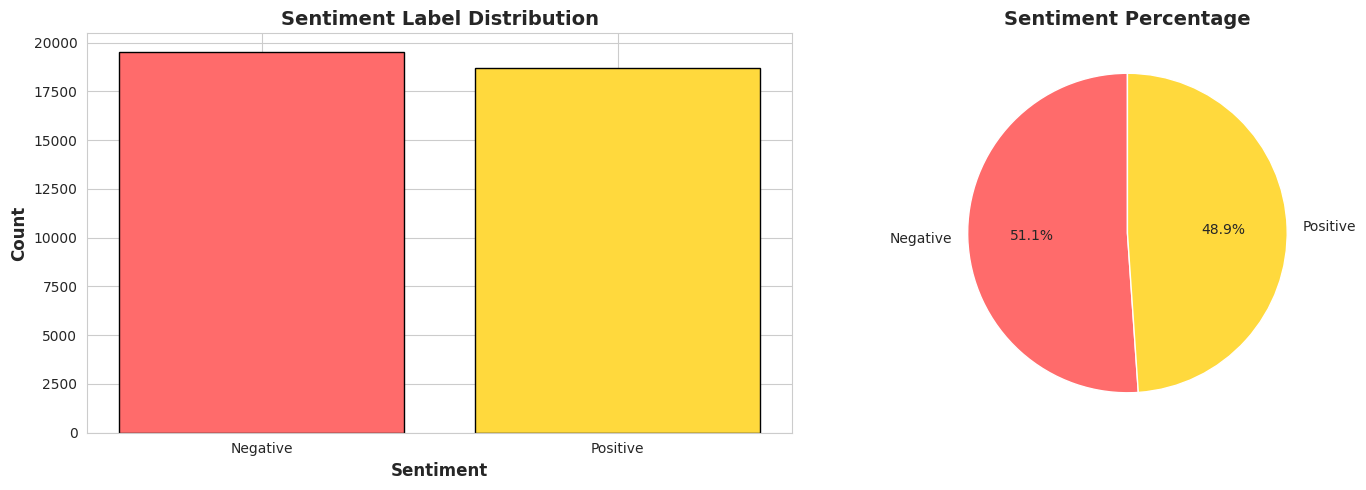


Sentiment labels created!

Sentiment distribution:
sentiment_name
Negative    19496
Positive    18669
Name: count, dtype: int64


In [36]:
print(" Creating sentiment labels from ratings...")

def rating_to_sentiment(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating >= 4:
        return 1   # Positive
    else:
        return None  # Drop 3-star (neutral)

df['sentiment_label'] = df['rating'].apply(rating_to_sentiment)
df = df[df['sentiment_label'].notna()].copy()
df['sentiment_label'] = df['sentiment_label'].astype(int)
df['sentiment_name'] = df['sentiment_label'].map({0: 'Negative', 1: 'Positive'})

print(f"Dataset size after dropping neutral: {len(df):,}")
print(df['sentiment_name'].value_counts())



# Visualize sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sentiment_counts = df['sentiment_name'].value_counts()
colors = ['#ff6b6b', '#ffd93d', '#6bcf7f']

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Sentiment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')

axes[1].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Sentiment Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSentiment labels created!")
print(f"\nSentiment distribution:")
print(df['sentiment_name'].value_counts())

STEP 8: EXTRACT TIME FEATURES

Extracting time features...
shape before timestamp conversion: (47822, 14)
df['timestamp'] dtype before conversion: int64
df['timestamp'] head before conversion:
0    1523488186561
1    1477254696000
2    1511654795258
3    1502736031291
4    1504556447031
Name: timestamp, dtype: int64
df['timestamp'] isnull().sum() after conversion: 0
df['timestamp'] head after conversion:
0   2018-04-11 23:09:46.561
1   2016-10-23 20:31:36.000
2   2017-11-26 00:06:35.258
3   2017-08-14 18:40:31.291
4   2017-09-04 20:20:47.031
Name: timestamp, dtype: datetime64[ns]
shape after timestamp conversion: (47822, 14)


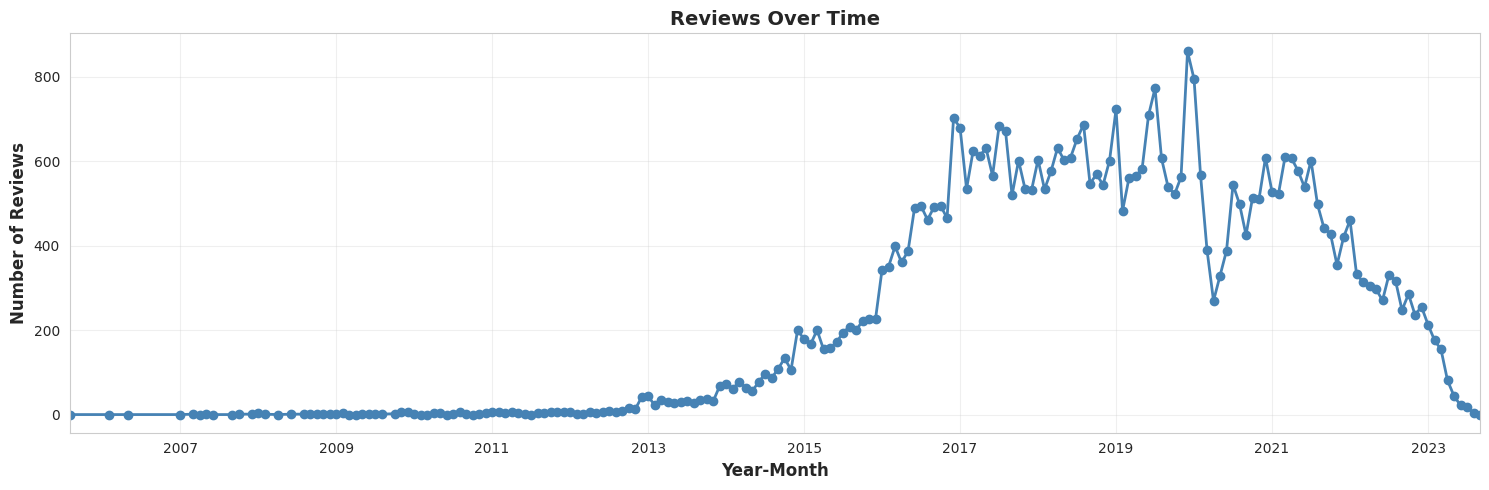

Time features extracted!
Date range: 2005-08-04 02:16:01 to 2023-09-02 22:12:25.728000
First 5 dates: [Timestamp('2018-04-11 00:00:00'), Timestamp('2016-10-23 00:00:00'), Timestamp('2017-11-26 00:00:00'), Timestamp('2017-08-14 00:00:00'), Timestamp('2017-09-04 00:00:00')]


In [15]:
print("Extracting time features...")

print(f"shape before timestamp conversion: {df.shape}")
print(f"df['timestamp'] dtype before conversion: {df['timestamp'].dtype}")
print(f"df['timestamp'] head before conversion:\n{df['timestamp'].head()}")

# Convert timestamp to datetime, coercing errors to NaT (assuming unit is milliseconds)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')


print(f"df['timestamp'] isnull().sum() after conversion: {df['timestamp'].isnull().sum()}")
print(f"df['timestamp'] head after conversion:\n{df['timestamp'].head()}")
print(f"shape after timestamp conversion: {df.shape}")

# Drop rows where timestamp conversion failed
df.dropna(subset=['timestamp'], inplace=True)

# Check if df is empty after dropping NaT timestamps
if df.empty:
    print("Warning: DataFrame is empty after dropping invalid timestamps. Cannot extract time features or plot.")
else:
    # Create df['date'] as requested, ensuring it's normalized to midnight
    df['date'] = df['timestamp'].dt.normalize()
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['year_month'] = df['timestamp'].dt.to_period('M')

    # Visualize reviews over time
    monthly_reviews = df.groupby('year_month').size()

    if not monthly_reviews.empty:
        plt.figure(figsize=(15, 5))
        monthly_reviews.plot(kind='line', marker='o', color='steelblue', linewidth=2)
        plt.xlabel('Year-Month', fontsize=12, fontweight='bold')
        plt.ylabel('Number of Reviews', fontsize=12, fontweight='bold')
        plt.title('Reviews Over Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Time features extracted!")
        print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print(f"First 5 dates: {df['date'].head().tolist()}") # Display sample dates
    else:
        print("Warning: No valid monthly reviews to plot after extracting time features.")

## STEP 9: HELPFULNESS NORMALIZATION (PAPER STYLE)

Normalizing helpfulness scores to a 1-5 scale for consistency with sentiment and ratings, as per the paper's approach.

In [16]:
print(" Normalizing helpfulness...")

df['helpful_vote'] = df['helpful_vote'].fillna(0)

# Avoid division by zero if helpful_vote has no variance
min_helpful_vote = df['helpful_vote'].min()
max_helpful_vote = df['helpful_vote'].max()

if max_helpful_vote == min_helpful_vote:
    df['helpful_norm'] = 3.0 # Assign neutral if no range
else:
    df['helpful_norm'] = 1 + (
        (df['helpful_vote'] - min_helpful_vote) /
        (max_helpful_vote - min_helpful_vote)
    ) * 4

print("Helpfulness normalized (1–5 scale)")
print(f"\nNormalized helpfulness score distribution (1-5 scale):")
print(df['helpful_norm'].describe())

 Normalizing helpfulness...
Helpfulness normalized (1–5 scale)

Normalized helpfulness score distribution (1-5 scale):
count    47822.000000
mean         1.008948
std          0.047246
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: helpful_norm, dtype: float64


STEP 10: TEXT STATISTICS

Calculating text statistics...


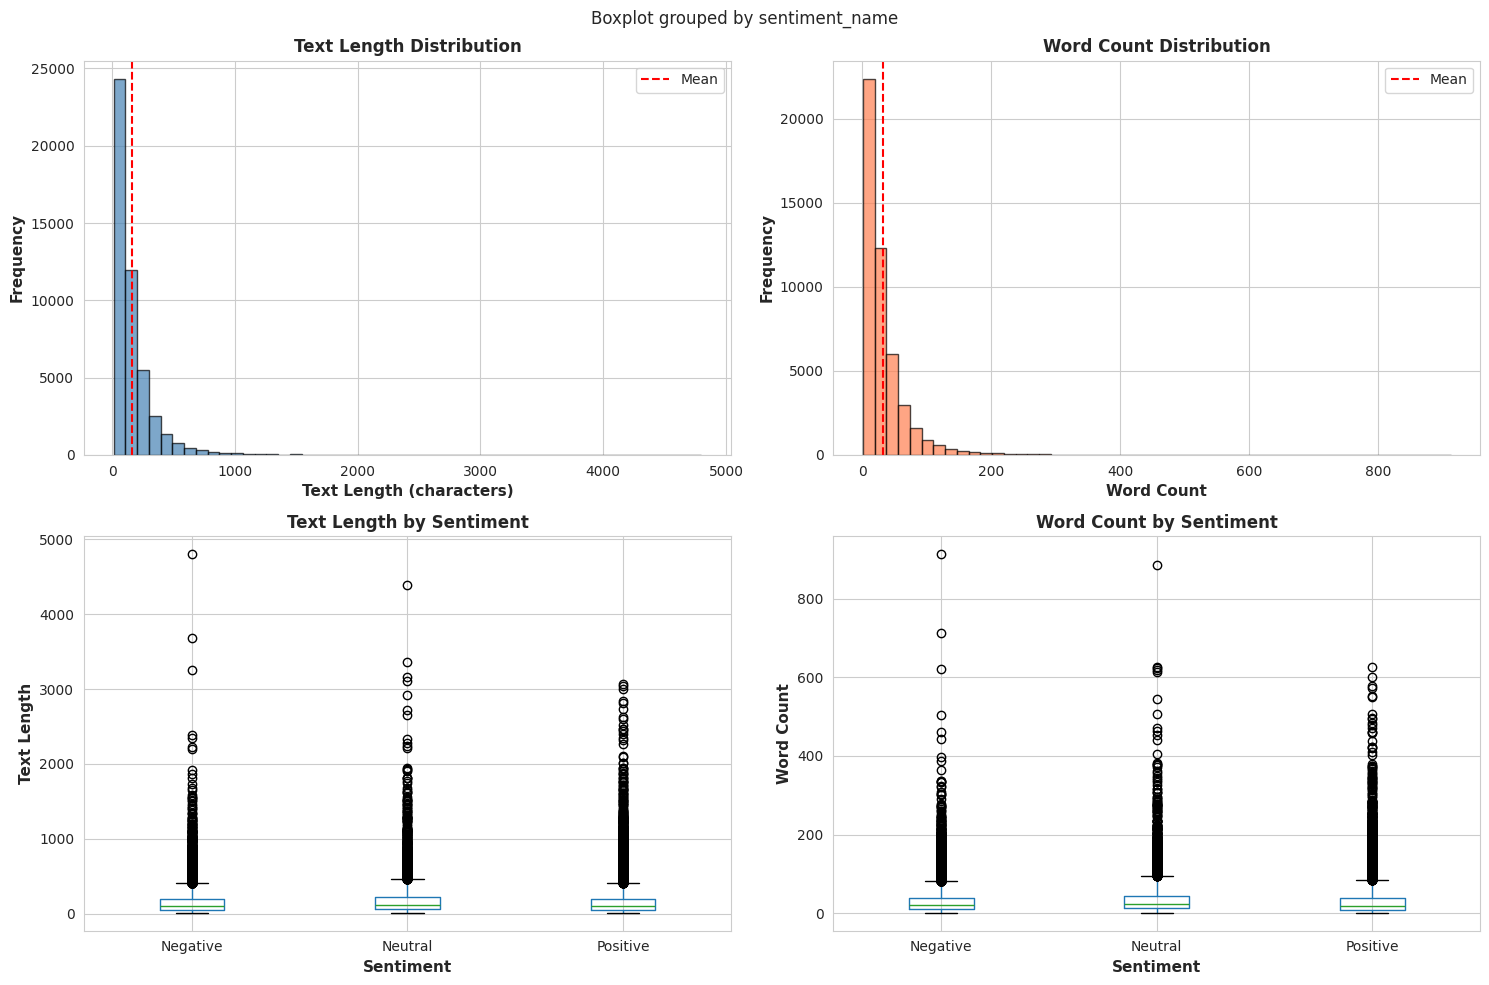


Text Statistics:
Average text length: 159 characters
Average word count: 32 words
Max text length: 4799 characters
Min text length: 11 characters


In [17]:
print("Calculating text statistics...")

# Ensure 'sentiment_label' and 'sentiment_name' columns exist for plotting
if 'sentiment_name' not in df.columns or 'sentiment_label' not in df.columns:
    print("Warning: 'sentiment_name' or 'sentiment_label' column not found. Attempting to regenerate from 'rating'.")
    # Re-define rating_to_sentiment function locally for robustness
    def rating_to_sentiment(rating):
        if rating <= 2:
            return 0  # Negative
        elif rating == 3:
            return 1  # Neutral
        else:
            return 2  # Positive

    if 'rating' in df.columns:
        df['sentiment_label'] = df['rating'].apply(rating_to_sentiment)
        df['sentiment_name'] = df['sentiment_label'].map({
            0: 'Negative',
            1: 'Neutral',
            2: 'Positive'
        })
        print("'sentiment_label' and 'sentiment_name' columns regenerated.")
    else:
        print("Error: 'rating' column not found, cannot regenerate sentiment columns. Please ensure previous steps creating 'rating' are run.")
        # If 'rating' is missing, the plots relying on sentiment will still fail.
        # The user needs to run the preceding data loading and cleaning steps.


# Calculate text length
df['text_length'] = df['text_cleaned'].str.len()
df['word_count'] = df['text_cleaned'].str.split().str.len()

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Text length distribution
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Text Length (characters)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Text Length Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['text_length'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0, 1].axvline(df['word_count'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Text length by sentiment (only if sentiment_name exists)
if 'sentiment_name' in df.columns:
    df.boxplot(column='text_length', by='sentiment_name', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Sentiment', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Text Length', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Text Length by Sentiment', fontsize=12, fontweight='bold')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=0)

    # Word count by sentiment
    df.boxplot(column='word_count', by='sentiment_name', ax=axes[1, 1])
    axes[1, 1].set_xlabel('Sentiment', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Word Count', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Word Count by Sentiment', fontsize=12, fontweight='bold')
    plt.sca(axes[1, 1])
    plt.xticks(rotation=0)
else:
    # If sentiment_name could not be created, disable these plots to avoid error
    axes[1, 0].set_visible(False)
    axes[1, 1].set_visible(False)
    print("Skipping sentiment-based plots as 'sentiment_name' column is not available.")

plt.tight_layout()
plt.show()

print(f"\nText Statistics:")
print(f"Average text length: {df['text_length'].mean():.0f} characters")
print(f"Average word count: {df['word_count'].mean():.0f} words")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Min text length: {df['text_length'].min()} characters")

STEP 11: BASELINE MODEL - VADER SENTIMENT ANALYSIS

VADER SENTIMENT ANALYSIS (BASELINE)

Running VADER analysis...
VADER analysis complete!

VADER Accuracy: 0.6691 (66.91%)


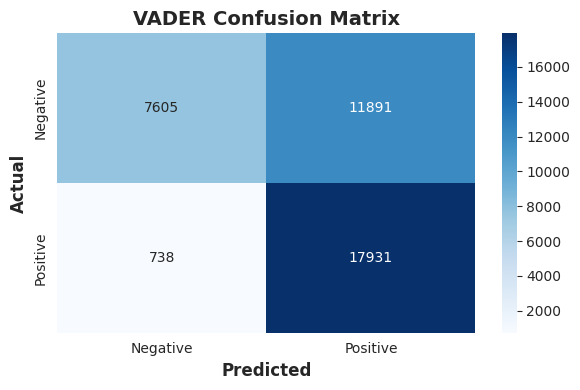


VADER Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.39      0.55     19496
    Positive       0.60      0.96      0.74     18669

    accuracy                           0.67     38165
   macro avg       0.76      0.68      0.64     38165
weighted avg       0.76      0.67      0.64     38165



In [37]:
print("=" * 80)
print("VADER SENTIMENT ANALYSIS (BASELINE)")
print("=" * 80)

# Initialize VADER
vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get VADER sentiment scores"""
    scores = vader.polarity_scores(text)
    return scores

# Apply VADER
print("\nRunning VADER analysis...")
vader_scores = df['text_cleaned'].apply(get_vader_sentiment)

# Extract scores
df['vader_neg']      = vader_scores.apply(lambda x: x['neg'])
df['vader_neu']      = vader_scores.apply(lambda x: x['neu'])
df['vader_pos']      = vader_scores.apply(lambda x: x['pos'])
df['vader_compound'] = vader_scores.apply(lambda x: x['compound'])

# PAPER-STYLE SENTIMENT NORMALIZATION
# Step 1: (-1 to 1) → (0 to 1)
df['sentiment_01'] = (df['vader_compound'] + 1) / 2
# Step 2: (0 to 1) → (1 to 5)
df['sentiment_score_vader'] = 1 + df['sentiment_01'] * 4

# 2-CLASS: convert normalized score to 0=Negative, 1=Positive
def vader_to_label(score):
    if score >= 3.0:
        return 1   # Positive
    else:
        return 0   # Negative

df['vader_sentiment'] = df['sentiment_score_vader'].apply(vader_to_label)
df['vader_sentiment_name'] = df['vader_sentiment'].map({
    0: 'Negative',
    1: 'Positive'
})

print("VADER analysis complete!")

# Evaluate VADER
vader_accuracy = accuracy_score(df['sentiment_label'], df['vader_sentiment'])
print(f"\nVADER Accuracy: {vader_accuracy:.4f} ({vader_accuracy*100:.2f}%)")

# Confusion matrix
cm_vader = confusion_matrix(df['sentiment_label'], df['vader_sentiment'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.title('VADER Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification report
print("\nVADER Classification Report:")
print(classification_report(df['sentiment_label'], df['vader_sentiment'],
                            target_names=['Negative', 'Positive']))

STEP 12: VADER SCORE DISTRIBUTION

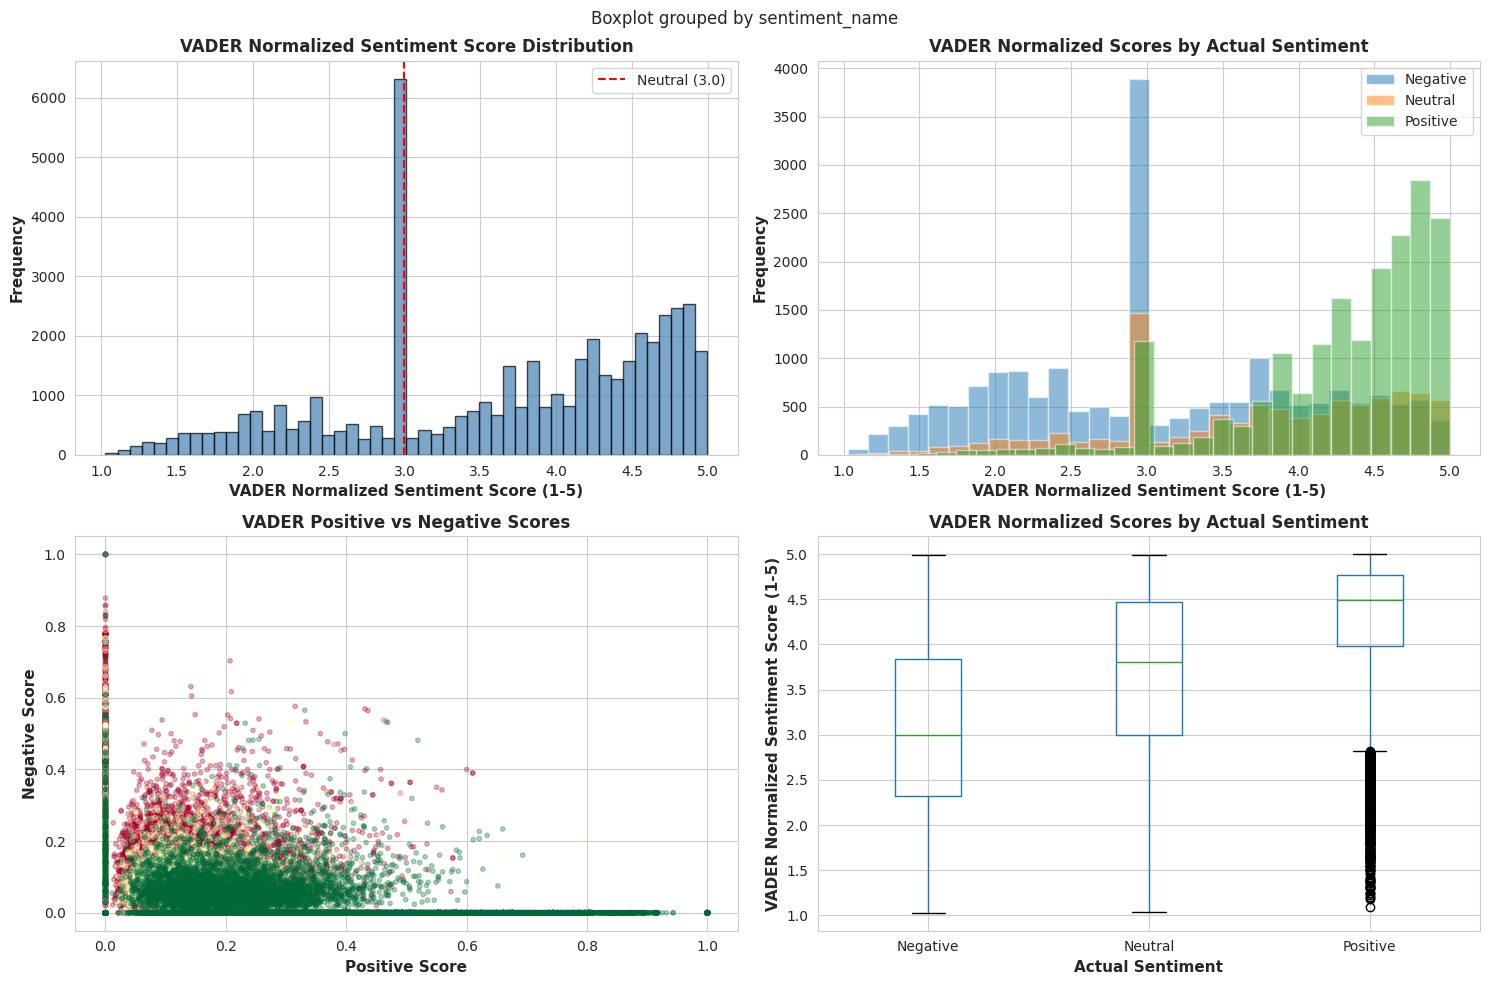

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Compound score distribution (using the paper's normalized sentiment score)
axes[0, 0].hist(df['sentiment_score_vader'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('VADER Normalized Sentiment Score (1-5)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('VADER Normalized Sentiment Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(3.0, color='red', linestyle='--', label='Neutral (3.0)') # Neutral is now around 3
axes[0, 0].legend()

# Compound score by actual sentiment
for sentiment in [0, 1, 2]:
    subset = df[df['sentiment_label'] == sentiment]['sentiment_score_vader']
    axes[0, 1].hist(subset, bins=30, alpha=0.5,
                   label=['Negative', 'Neutral', 'Positive'][sentiment])
axes[0, 1].set_xlabel('VADER Normalized Sentiment Score (1-5)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('VADER Normalized Scores by Actual Sentiment', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# Positive vs Negative scores (still using raw vader_pos/neg as they are components)
axes[1, 0].scatter(df['vader_pos'], df['vader_neg'], alpha=0.3, c=df['sentiment_label'],
                  cmap='RdYlGn', s=10)
axes[1, 0].set_xlabel('Positive Score', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Negative Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('VADER Positive vs Negative Scores', fontsize=12, fontweight='bold')

# Compound score boxplot by sentiment
df.boxplot(column='sentiment_score_vader', by='sentiment_name', ax=axes[1, 1])
axes[1, 1].set_xlabel('Actual Sentiment', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('VADER Normalized Sentiment Score (1-5)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('VADER Normalized Scores by Actual Sentiment', fontsize=12, fontweight='bold')
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

LOGISTIC REGRESSION + SVM (TF-IDF)

Training Logistic Regression...
Logistic Regression Accuracy: 0.8715 (87.15%)

Training LinearSVC...
LinearSVC Accuracy: 0.8641 (86.41%)

Best ML model: Logistic Regression (87.15%)


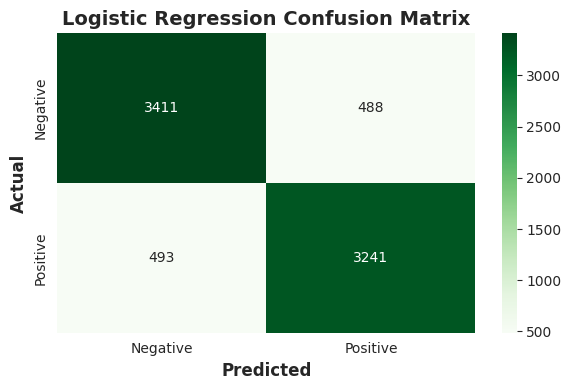

In [38]:
print("=" * 80)
print("LOGISTIC REGRESSION + SVM (TF-IDF)")
print("=" * 80)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

X = df["text_cleaned"]
y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Improved TF-IDF: 20K features, trigrams, sublinear_tf
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    stop_words="english"
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Logistic Regression - 2 class (no multinomial needed)
print("\nTraining Logistic Regression...")
log_model = LogisticRegression(
    max_iter=1000, C=5,
    class_weight="balanced",
    solver="lbfgs"
)
log_model.fit(X_train_tfidf, y_train)
y_pred_lr = log_model.predict(X_test_tfidf)
log_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {log_accuracy:.4f} ({log_accuracy*100:.2f}%)")

# LinearSVC
print("\nTraining LinearSVC...")
svm_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"LinearSVC Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

# Pick best
if svm_accuracy >= log_accuracy:
    y_pred_logistic = y_pred_svm
    best_ml_accuracy = svm_accuracy
    best_ml_name = "LinearSVC"
else:
    y_pred_logistic = y_pred_lr
    best_ml_accuracy = log_accuracy
    best_ml_name = "Logistic Regression"

print(f"\nBest ML model: {best_ml_name} ({best_ml_accuracy*100:.2f}%)")

cm_log = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted", fontsize=12, fontweight="bold")
plt.ylabel("Actual", fontsize=12, fontweight="bold")
plt.title(f"{best_ml_name} Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()

STEP 13: PREPARE DATA FOR DISTILBERT

In [40]:
print("=" * 80)
print("DISTILBERT FINE-TUNING PREPARATION")
print("=" * 80)

TRAIN_SIZE = 20000   # 10000 per class

train_df = df.groupby('sentiment_label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), TRAIN_SIZE // 2))
).reset_index(drop=True)

print(f"Selected {len(train_df):,} reviews for DistilBERT training")
print(train_df['sentiment_name'].value_counts())

X = train_df['text_cleaned'].values
y = train_df['sentiment_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")


DISTILBERT FINE-TUNING PREPARATION
Selected 20,000 reviews for DistilBERT training
sentiment_name
Negative    10000
Positive    10000
Name: count, dtype: int64
Training set: 16,000
Test set: 4,000


STEP 14: TOKENIZE DATA FOR DISTILBERT

In [41]:
print("Tokenizing text for DistilBERT...")

# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Tokenize
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

print("Tokenization complete!")
print(f"Train encodings shape: {train_encodings['input_ids'].shape}")
print(f"Test encodings shape: {test_encodings['input_ids'].shape}")

Tokenizing text for DistilBERT...
Tokenization complete!
Train encodings shape: torch.Size([16000, 128])
Test encodings shape: torch.Size([4000, 128])


STEP 15: CREATE PYTORCH DATASET

In [43]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

print("PyTorch datasets created!")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

PyTorch datasets created!
Train dataset size: 16000
Test dataset size: 4000


STEP 16: LOAD AND CONFIGURE DISTILBERT MODEL

In [44]:
print("Loading DistilBERT model...")

# Load pre-trained model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  # 2 sentiment classes
)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Model loaded on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda
Model parameters: 66,955,010


STEP 17: DEFINE TRAINING ARGUMENTS

In [46]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

print("Training arguments configured!")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Batch size: {training_args.per_device_train_batch_size}")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments configured!
Epochs: 4
Batch size: 16


STEP 18: TRAIN DISTILBERT MODEL

In [47]:
# Define trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print("Starting training...")
import os
output_dir = './models/sentiment_distilbert'

try:
    # Train
    trainer.train()
    print("\nTraining complete!")

    # Evaluate
    print("\nEvaluating model...")
    eval_results = trainer.evaluate()
    print(f"Evaluation Results: {eval_results}")

except Exception as e:
    print(f"Training skipped or failed: {e}")
    print("Continuing with VADER results...")

Starting training...


Epoch,Training Loss,Validation Loss
1,0.227349,0.282156
2,0.180914,0.316410
3,0.085986,0.398953
4,0.039697,0.469562


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete!

Evaluating model...


Evaluation Results: {'eval_loss': 0.2820481061935425, 'eval_runtime': 13.3432, 'eval_samples_per_second': 299.778, 'eval_steps_per_second': 9.368, 'epoch': 4.0}


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
# Save model
trainer.save_model("/content/drive/MyDrive/distilbert_model")

# Save tokenizer
tokenizer.save_pretrained("/content/drive/MyDrive/distilbert_model")

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


STEP 20: EVALUATE DISTILBERT MODEL

DistilBERT Accuracy: 0.8982 (89.83%)


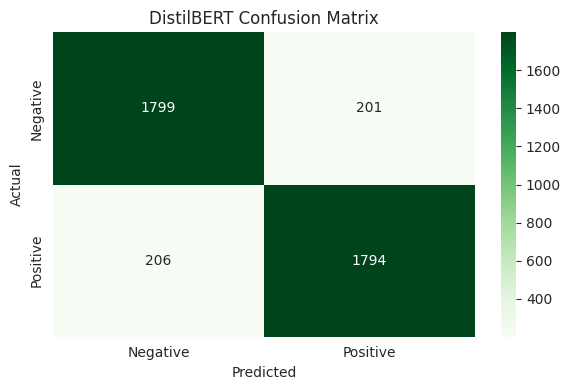

              precision    recall  f1-score   support

    Negative       0.90      0.90      0.90      2000
    Positive       0.90      0.90      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



In [51]:
# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)


# Calculate accuracy
bert_accuracy = accuracy_score(y_test, y_pred)
print(f"DistilBERT Accuracy: {bert_accuracy:.4f} ({bert_accuracy*100:.2f}%)")


# Confusion matrix
cm_bert = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('DistilBERT Confusion Matrix')
plt.tight_layout(); plt.show()


# Classification report
print(classification_report(y_test, y_pred,
      target_names=['Negative', 'Positive']))

STEP 21: COMPARE VADER VS DISTILBERT

MODEL COMPARISON: VADER vs LOGISTIC REGRESSION vs DISTILBERT
VADER Accuracy        : 66.91%
Best ML Accuracy      : 87.15%
DistilBERT Accuracy   : 89.83%

Comparison Table:
                  Model  Accuracy             Type
       VADER (Baseline)  0.669095       Rule-based
    Logistic Regression  0.871479 Machine Learning
DistilBERT (Fine-tuned)  0.898250    Deep Learning


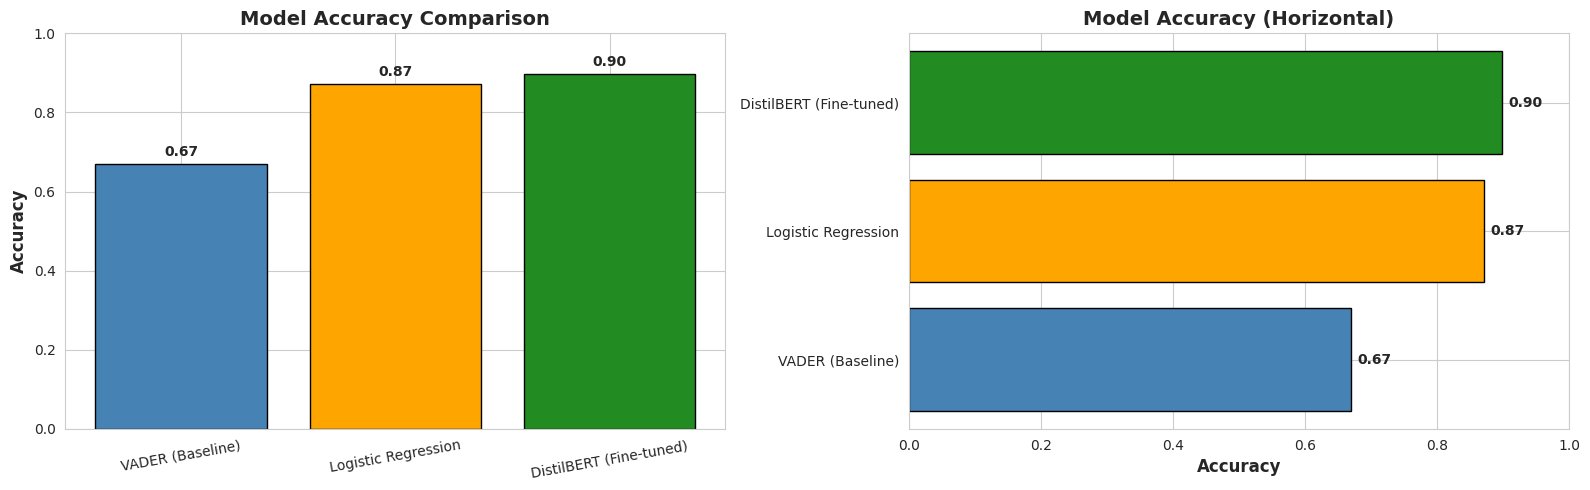

In [53]:
print("=" * 80)
print("MODEL COMPARISON: VADER vs LOGISTIC REGRESSION vs DISTILBERT")
print("=" * 80)

# Accuracies already computed in previous cells
vader_acc   = accuracy_score(df['sentiment_label'], df['vader_sentiment'])
log_acc     = best_ml_accuracy
bert_acc    = bert_accuracy

print(f"VADER Accuracy        : {vader_acc*100:.2f}%")
print(f"Best ML Accuracy      : {log_acc*100:.2f}%")
print(f"DistilBERT Accuracy   : {bert_acc*100:.2f}%")

# Comparison table
comparison = pd.DataFrame({
    'Model':    ['VADER (Baseline)', best_ml_name, 'DistilBERT (Fine-tuned)'],
    'Accuracy': [vader_acc, log_acc, bert_acc],
    'Type':     ['Rule-based', 'Machine Learning', 'Deep Learning']
})

print("\nComparison Table:")
print(comparison.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    comparison['Model'],
    comparison['Accuracy'],
    color=['steelblue', 'orange', 'forestgreen'],
    edgecolor='black'
)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=10)

for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].barh(
    comparison['Model'],
    comparison['Accuracy'],
    color=['steelblue', 'orange', 'forestgreen'],
    edgecolor='black'
)
axes[1].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Model Accuracy (Horizontal)', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])

for i, v in enumerate(comparison['Accuracy']):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

MODEL COMPARISON GRAPH (ACTUAL RESULTS)


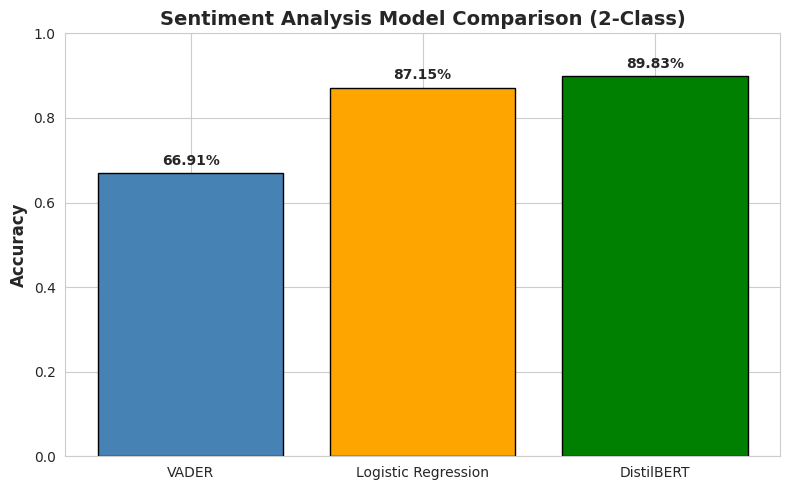

In [54]:
import matplotlib.pyplot as plt

print("=" * 80)
print("MODEL COMPARISON GRAPH (ACTUAL RESULTS)")
print("=" * 80)

# Use actual computed accuracies from previous cells
models     = ['VADER', best_ml_name, 'DistilBERT']
accuracies = [vader_acc, best_ml_accuracy, bert_accuracy]

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies,
               color=['steelblue', 'orange', 'green'],
               edgecolor='black')

# Labels and title
plt.title('Sentiment Analysis Model Comparison (2-Class)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim(0, 1)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f'{yval*100:.2f}%',
             ha='center',
             fontweight='bold')

plt.tight_layout()
plt.show()

STEP 22: GENERATE SENTIMENT SCORES FOR ALL REVIEWS

STEP 25: CREATE SUPPLIER MAPPING (SYNTHETIC)

GENERATING SENTIMENT SCORES FOR SUPPLY CHAIN INTEGRATION

Predicting sentiment for all reviews...


Sentiment scores generated (1-5 scale)!

Sentiment score distribution:
count    38165.000000
mean         2.983178
std          1.999955
min          1.000000
25%          1.000000
50%          1.000000
75%          5.000000
max          5.000000
Name: sentiment_score, dtype: float64

Sentiment counts:
bert_sentiment
Negative    19243
Positive    18922
Name: count, dtype: int64


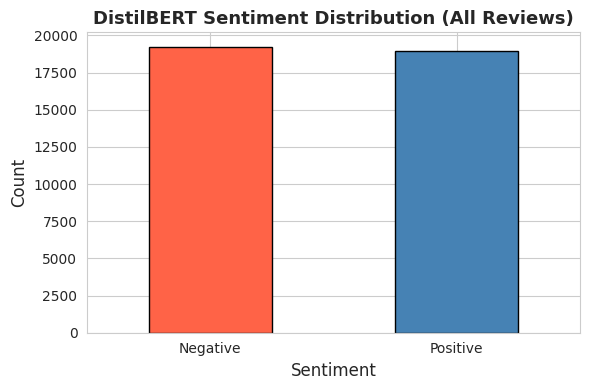

In [55]:
print("=" * 80)
print("GENERATING SENTIMENT SCORES FOR SUPPLY CHAIN INTEGRATION")
print("=" * 80)

# Use DistilBERT to predict sentiment for all reviews
print("\nPredicting sentiment for all reviews...")

# Tokenize all reviews
all_encodings = tokenizer(
    list(df['text_cleaned']),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

# Create dataset with dummy labels
all_dataset = SentimentDataset(all_encodings, np.zeros(len(df), dtype=int))

# Predict
all_predictions = trainer.predict(all_dataset)
df['bert_sentiment'] = np.argmax(all_predictions.predictions, axis=1)

# ============================================================================
# PAPER-STYLE SENTIMENT NORMALIZATION (2-CLASS)
# ============================================================================

# Step 1: Convert labels → (0 to 1)
# 0 = Negative → 0.0
# 1 = Positive → 1.0
df['sentiment_01'] = df['bert_sentiment'].map({
    0: 0.0,
    1: 1.0
})

# Step 2: Convert (0 to 1) → (1 to 5)
df['sentiment_score'] = 1 + df['sentiment_01'] * 4

print("Sentiment scores generated (1-5 scale)!")
print(f"\nSentiment score distribution:")
print(df['sentiment_score'].describe())

print(f"\nSentiment counts:")
print(df['bert_sentiment'].map({0: 'Negative', 1: 'Positive'}).value_counts())

# Plot distribution
plt.figure(figsize=(6, 4))
df['bert_sentiment'].map({0: 'Negative', 1: 'Positive'}).value_counts().plot(
    kind='bar',
    color=['tomato', 'steelblue'],
    edgecolor='black'
)
plt.title('DistilBERT Sentiment Distribution (All Reviews)', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

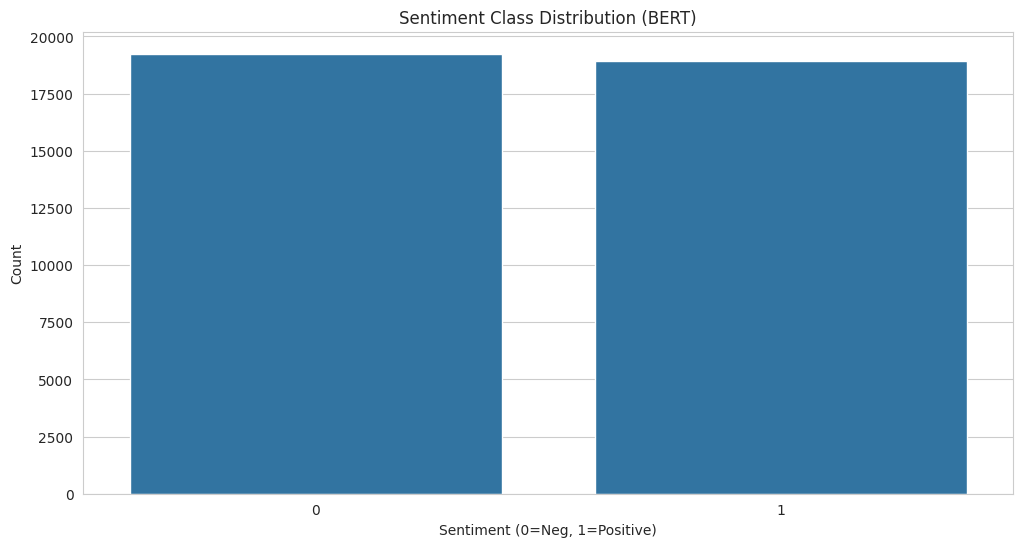

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['bert_sentiment'])
plt.title("Sentiment Class Distribution (BERT)")
plt.xlabel("Sentiment (0=Neg, 1=Positive)")
plt.ylabel("Count")
plt.show()

# STEP 23 :Normalize Helpfulness

In [58]:
# Fill missing
df['helpful_vote'] = df['helpful_vote'].fillna(0)

# Normalize (1–5 scale)
df['helpful_norm'] = 1 + (
    (df['helpful_vote'] - df['helpful_vote'].min()) /
    (df['helpful_vote'].max() - df['helpful_vote'].min())
) * 4

print("Helpfulness normalized!")

Helpfulness normalized!


In [59]:
df['date'] = pd.to_datetime(df['timestamp']).dt.date

STEP 24: Create Daily Sales

In [60]:
# The 'date' column is already normalized in STEP 8. We just need to group.

daily_sales = df.groupby(['asin', 'date']).size().reset_index(name='daily_sales')

print(" Daily sales created!")

 Daily sales created!


## STEP 25: FEATURE ENGINEERING - COMBINED SCORE

In [61]:
# ============================================================================
#FEATURE AGGREGATION
# ============================================================================

features = df.groupby(['asin', 'date']).agg({
    'rating': 'mean',
    'sentiment_score': 'mean',
    'helpful_norm': 'mean',
    'year': 'first',
    'month': 'first',
    'year_month': 'first',
    'verified_purchases': lambda x: (x == True).mean()
}).reset_index()

In [62]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchases,...,vader_neg,vader_neu,vader_pos,vader_compound,sentiment_01,sentiment_score_vader,vader_sentiment,vader_sentiment_name,bert_sentiment,sentiment_score
0,1.0,One Star,material is horrible and cheap,[],B077K3LK4T,B077K3LK4T,AGFK5FSM3W2L77QEYIES27MR7SQQ,2018-04-11 23:09:46.561,0,True,...,0.467,0.533,0.000,-0.5423,0.0,1.9154,0,Negative,0,1.0
1,1.0,Not Worth It,"For the amount of money this cost, it is SO NO...",[],B010H32ZES,B010H32ZES,AE3OTXSTSOFPKQ3FKYXXSWEKOIZQ,2016-10-23 20:31:36.000,1,True,...,0.045,0.819,0.136,0.5935,0.0,4.1870,1,Positive,0,1.0
2,1.0,One Star,Returning this item. They are almost sky blue ...,[],B00UTQFS52,B00UTQFS52,AFLDNLRW234OQLCRSOIXLFUSNRKA,2017-11-26 00:06:35.258,3,True,...,0.000,1.000,0.000,0.0000,0.0,3.0000,1,Positive,0,1.0
3,1.0,I ordered x-large and it is more like an x-small,Sizes are way off... I ordered x-large and it ...,[],B01M0LEW2V,B01M0LEW2V,AHGOJFOGIK3CH5PCSJG7JFGLPUZQ,2017-08-14 18:40:31.291,0,True,...,0.000,0.811,0.189,0.4201,0.0,3.8402,1,Positive,0,1.0
4,1.0,To my sorrow as it was a pretty bracelet.,The bracelet has already broken and is turning...,[],B01J5A2FRQ,B01J5A2FRQ,AHP7J32KNMT7VZE2HHSKWF45DHEA,2017-09-04 20:20:47.031,0,True,...,0.274,0.591,0.135,-0.5106,0.0,1.9788,0,Negative,0,1.0


In [63]:
import pandas as pd

col_types = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values
})

print(col_types)

                   Column       Data Type
0                  rating         float64
1                   title          object
2                    text          object
3                  images          object
4                    asin          object
5             parent_asin          object
6                 user_id          object
7               timestamp  datetime64[ns]
8            helpful_vote           int64
9      verified_purchases            bool
10                 target           int64
11           text_cleaned          object
12        sentiment_label           int64
13         sentiment_name          object
14                   date          object
15                   year           int32
16                  month           int32
17             year_month       period[M]
18           helpful_norm         float64
19            text_length           int64
20             word_count           int64
21              vader_neg         float64
22              vader_neu         

In [64]:
# Save full dataset
file_path = '/content/drive/MyDrive/amazon_full_processed.csv'

df.to_csv(file_path, index=False)

print("Full dataset saved successfully!")

Full dataset saved successfully!


In [65]:
# STEP 5: MERGE DATA

# Ensure 'date' columns have consistent datetime type
daily_sales['date'] = pd.to_datetime(daily_sales['date'])
features['date'] = pd.to_datetime(features['date'])


final_df = daily_sales.merge(features, on=['asin', 'date'])

print("Final dataset created!")
print(final_df.head())

Final dataset created!
         asin       date  daily_sales  rating  sentiment_score  helpful_norm  \
0  0610318861 2020-05-25            1     2.0              1.0      1.000000   
1  0629150591 2017-01-02            1     1.0              1.0      1.015686   
2  0956695930 2016-04-09            1     5.0              5.0      1.000000   
3  6152004349 2018-04-15            1     4.0              5.0      1.000000   
4  7106116521 2015-08-10            1     1.0              1.0      1.000000   

   year  month year_month  verified_purchases  
0  2020      5    2020-05                 1.0  
1  2017      1    2017-01                 1.0  
2  2016      4    2016-04                 1.0  
3  2018      4    2018-04                 1.0  
4  2015      8    2015-08                 1.0  


Combined feature

In [66]:
final_df['SC'] = (
    final_df['rating'] +
    final_df['sentiment_score'] +
    final_df['helpful_norm']
) / 3

print("Combined feature (SC) created!")
print(final_df[['rating', 'sentiment_score', 'helpful_norm', 'SC']].head())

Combined feature (SC) created!
   rating  sentiment_score  helpful_norm        SC
0     2.0              1.0      1.000000  1.333333
1     1.0              1.0      1.015686  1.005229
2     5.0              5.0      1.000000  3.666667
3     4.0              5.0      1.000000  3.333333
4     1.0              1.0      1.000000  1.000000


STEP 6: FEATURE IMPORTANCE

In [67]:
from sklearn.ensemble import RandomForestRegressor

X = final_df[['rating', 'sentiment_score', 'helpful_norm']]
y = final_df['daily_sales']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

print("\n Feature Importance:")
for f, imp in zip(X.columns, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")


 Feature Importance:
rating: 0.3650
sentiment_score: 0.4558
helpful_norm: 0.1792


In [68]:
final_df.head()

,asin,date,daily_sales,rating,sentiment_score,helpful_norm,year,month,year_month,verified_purchases,SC
0,0610318861,2020-05-25,1,2.0,1.0,1.000000,2020,5,2020-05,1.0,1.333333
1,0629150591,2017-01-02,1,1.0,1.0,1.015686,2017,1,2017-01,1.0,1.005229
2,0956695930,2016-04-09,1,5.0,5.0,1.000000,2016,4,2016-04,1.0,3.666667
3,6152004349,2018-04-15,1,4.0,5.0,1.000000,2018,4,2018-04,1.0,3.333333
4,7106116521,2015-08-10,1,1.0,1.0,1.000000,2015,8,2015-08,1.0,1.000000


In [69]:
# Save final dataset
file_path = "/content/drive/MyDrive/final_dataset_before_lstm.csv"

final_df.to_csv(file_path, index=False)

print(f"Dataset saved to: {file_path}")

Dataset saved to: /content/drive/MyDrive/final_dataset_before_lstm.csv
